In [1]:
import pybamm

In [2]:
# Simulate a P2D model for 1 hour.
model = pybamm.lithium_ion.DFN()
sim = pybamm.Simulation(model)
sim.solve([0, 3600])

In [3]:
# View the full list of available variables
model.variable_names()

['Time [s]',
 'Time [min]',
 'Time [h]',
 'x [m]',
 'x_n [m]',
 'x_s [m]',
 'x_p [m]',
 'r_n [m]',
 'r_p [m]',
 'Current variable [A]',
 'Total current density [A.m-2]',
 'Current [A]',
 'C-rate',
 'Discharge capacity [A.h]',
 'Throughput capacity [A.h]',
 'Discharge energy [W.h]',
 'Throughput energy [W.h]',
 'Porosity',
 'Negative electrode porosity',
 'X-averaged negative electrode porosity',
 'Separator porosity',
 'X-averaged separator porosity',
 'Positive electrode porosity',
 'X-averaged positive electrode porosity',
 'Porosity change',
 'Negative electrode porosity change [s-1]',
 'X-averaged negative electrode porosity change [s-1]',
 'Separator porosity change [s-1]',
 'X-averaged separator porosity change [s-1]',
 'Positive electrode porosity change [s-1]',
 'X-averaged positive electrode porosity change [s-1]',
 'Negative electrode interface utilisation variable',
 'X-averaged negative electrode interface utilisation variable',
 'Negative electrode interface utilisation',


In [4]:
# Search for an OUTPUT variables containing a specific string. Print results as a line.
model.variables.search("SEI")

# Print the results as a list.
print("\n".join(k for k in model.variables.keys() if "current density" in k.lower()))

Results for 'SEI': ['Negative SEI concentration [mol.m-3]', 'X-averaged negative SEI concentration [mol.m-3]', 'Volume-averaged negative SEI concentration [mol.m-3]', 'Loss of lithium to negative SEI [mol]', 'Loss of capacity to negative SEI [A.h]', 'Negative electrode SEI interfacial current density [A.m-2]', 'X-averaged negative electrode SEI interfacial current density [A.m-2]', 'Positive SEI concentration [mol.m-3]', 'X-averaged positive SEI concentration [mol.m-3]', 'Volume-averaged positive SEI concentration [mol.m-3]', 'Loss of lithium to positive SEI [mol]', 'Loss of capacity to positive SEI [A.h]', 'Positive electrode SEI interfacial current density [A.m-2]', 'X-averaged positive electrode SEI interfacial current density [A.m-2]', 'Negative SEI on cracks concentration [mol.m-3]', 'X-averaged negative SEI on cracks concentration [mol.m-3]', 'Volume-averaged negative SEI on cracks concentration [mol.m-3]', 'Loss of lithium to negative SEI on cracks [mol]', 'Loss of capacity to n

In [5]:
# Couple a list of variables to plot. Plot the list with "sim.plot()".
variables = [
    "Electrolyte concentration [mol.m-3]",
    "Voltage [V]",
    "Discharge capacity [A.h]",
]
sim.plot(output_variables=variables)

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

In [6]:
# Plot multiple variables on the same plot by nesting lists.
sim.plot(
    [
        ["Electrode current density [A.m-2]", "Electrolyte current density [A.m-2]"],
        "Voltage [V]",
    ]
)

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

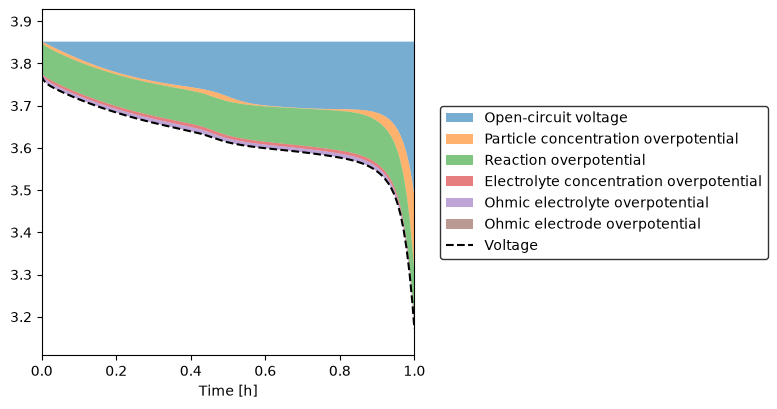

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [7]:
# Plot the contribution of the various overpotentials. The argument "split_by_electrode" can separate the contributions by electrode.
sim.plot_voltage_components(split_by_electrode=False)